In [1]:
# EXPLICABILIDAD DEL MODELO
#
# Un modelo que acierta pero no se puede explicar sirve de poco:
# nadie confia en una cifra sin saber de donde sale.
#
# Aqui se responden dos preguntas distintas:
#   1. QUE variables usa el modelo en general
#   2. POR QUE predice ESE precio para ESE piso concreto
#
# La segunda es la que permitira que la API devuelva, junto al
# precio estimado, una explicacion de como se ha llegado a el.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_parquet("../data/processed/model_dataset.parquet")
df = df[~df["is_outlier"]].copy()

NUMERICAS = ["area_sqm", "n_rooms", "sqm_per_room"]
CATEGORICAS = ["typology_grouped", "zona_modelo", "river_bank"]

X = df[NUMERICAS + CATEGORICAS]
y = np.log(df["monthly_price"])

print(f"{len(df)} registros")

856 registros


In [9]:
# ============================================================
# COMPROBACION FASE 1: ESTRUCTURA DEL TITULO
# ============================================================

df_fase1 = pd.read_sql("""
    SELECT
        v.listing_id,
        v.raw_title,
        v.typology,
        v.municipality,
        v.area_sqm,
        v.n_rooms,
        f.is_excluded
    FROM core.v_listing_mapped v
    JOIN core.fact_listing f
      ON f.listing_id = v.listing_id
    JOIN core.dim_zone z
      ON f.zone_id = z.zone_id
""", engine)

print("TOTAL ANTES DE EXCLUIR ERRORES GEOGRAFICOS:", len(df_fase1))
print("MARCADOS COMO EXCLUIDOS:", df_fase1["is_excluded"].sum())

# Numero de segmentos del titulo
n_segmentos = (
    df_fase1["raw_title"]
    .str.count(",")
    .add(1)
)

print("\nNUMERO DE SEGMENTOS:")
print(n_segmentos.value_counts(dropna=False).sort_index())

print("\nTOTAL CONTABILIZADO:", n_segmentos.notna().sum())

TOTAL ANTES DE EXCLUIR ERRORES GEOGRAFICOS: 888
MARCADOS COMO EXCLUIDOS: 2

NUMERO DE SEGMENTOS:
raw_title
1      8
2    102
3    571
4    206
5      1
Name: count, dtype: int64

TOTAL CONTABILIZADO: 888


In [10]:
print("DISTRIBUCION DE TIPOLOGIAS:")
print(df_fase1["typology"].value_counts(dropna=False))

print("\nTOTAL:", len(df_fase1))

DISTRIBUCION DE TIPOLOGIAS:
typology
flat         772
penthouse     59
studio        27
duplex        18
house         12
Name: count, dtype: int64

TOTAL: 888


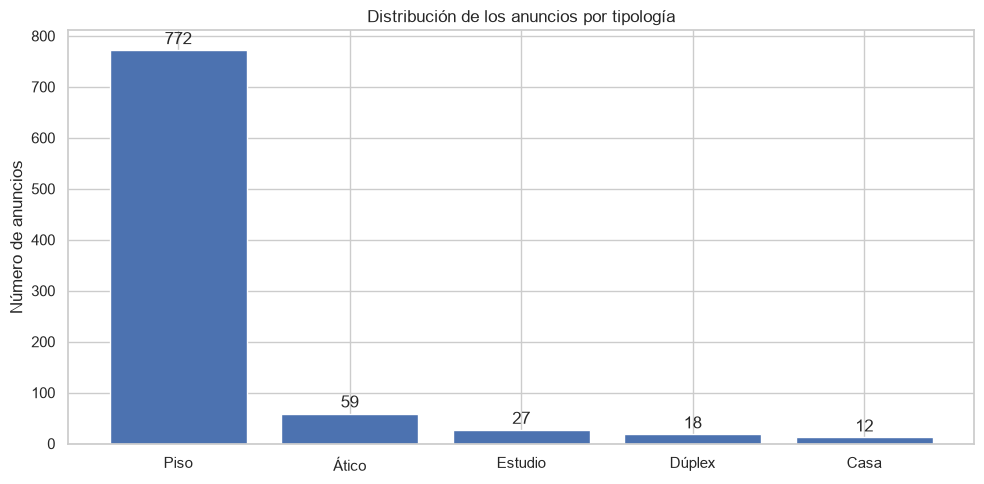

In [11]:
import matplotlib.pyplot as plt

# Distribución correcta de tipologías en la Fase 1 (888 anuncios)
tipologias = (
    df_fase1["typology"]
    .value_counts()
    .reindex(["flat", "penthouse", "studio", "duplex", "house"])
)

etiquetas = ["Piso", "Ático", "Estudio", "Dúplex", "Casa"]

plt.figure(figsize=(10, 5))

barras = plt.bar(etiquetas, tipologias.values)

plt.title("Distribución de los anuncios por tipología")
plt.ylabel("Número de anuncios")

# Mostrar valor encima de cada barra
for barra, valor in zip(barras, tipologias.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 5,
        str(valor),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [12]:
print("NUMERO DE MUNICIPIOS:", df_fase1["municipality"].nunique(dropna=False))

print("\nMUNICIPIOS Y NUMERO DE ANUNCIOS:")
print(
    df_fase1["municipality"]
    .value_counts(dropna=False)
    .sort_index()
    .to_string()
)

print("\nSIN LOS DOS ERRORES GEOGRAFICOS:")
df_validos = df_fase1[~df_fase1["is_excluded"]]

print("Numero de municipios:", df_validos["municipality"].nunique(dropna=False))
print(
    df_validos["municipality"]
    .value_counts(dropna=False)
    .sort_index()
    .to_string()
)

NUMERO DE MUNICIPIOS: 22

MUNICIPIOS Y NUMERO DE ANUNCIOS:
municipality
Arrigorriaga      3
Barakaldo        39
Barrika           1
Basauri           4
Berango           6
Bilbao          587
Derio             3
Erandio           2
Galdakao          5
Getxo           128
Gorliz            4
Leioa            14
Loiu              2
Ortuella          3
Plentzia         10
Portugalete      26
Santurtzi        28
Sestao            1
Sondika           3
Sopela           14
Urduliz           4
Zamudio           1

SIN LOS DOS ERRORES GEOGRAFICOS:
Numero de municipios: 22
municipality
Arrigorriaga      3
Barakaldo        39
Barrika           1
Basauri           4
Berango           6
Bilbao          587
Derio             3
Erandio           2
Galdakao          5
Getxo           126
Gorliz            4
Leioa            14
Loiu              2
Ortuella          3
Plentzia         10
Portugalete      26
Santurtzi        28
Sestao            1
Sondika           3
Sopela           14
Urduliz         

In [2]:
# Se entrena el modelo elegido sobre TODOS los datos.
# Hasta ahora se usaba validacion cruzada para medir sin hacer
# trampas. Ahora que ya sabemos que funciona, se entrena con
# todo para obtener el modelo definitivo.

prep = ColumnTransformer([
    ("num", "passthrough", NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAS),
])

modelo = GradientBoostingRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    random_state=RANDOM_STATE)

pipe = Pipeline([("prep", prep), ("modelo", modelo)])
pipe.fit(X, y)

# Nombres de las columnas tras la transformacion
nombres = (NUMERICAS +
           list(pipe.named_steps["prep"]
                .named_transformers_["cat"]
                .get_feature_names_out(CATEGORICAS)))

X_trans = pipe.named_steps["prep"].transform(X)
print(f"Variables tras transformar: {X_trans.shape[1]}")
print("(cada barrio se convierte en una columna propia)")

Variables tras transformar: 65
(cada barrio se convierte en una columna propia)


In [14]:
print("N_HABITACIONES")
print(df_fase1["n_rooms"].describe(percentiles=[0.01, 0.5, 0.99]))

print("\nSUPERFICIE")
print(df_fase1["area_sqm"].describe(percentiles=[0.01, 0.5, 0.99]))

N_HABITACIONES
count    888.000000
mean       2.362613
std        1.048561
min        0.000000
1%         0.000000
50%        2.000000
99%        5.000000
max        6.000000
Name: n_rooms, dtype: float64

SUPERFICIE
count    861.000000
mean      88.745645
std       35.503084
min       25.000000
1%        40.000000
50%       80.000000
99%      225.000000
max      420.000000
Name: area_sqm, dtype: float64


LAS 15 VARIABLES MAS INFLUYENTES
                             variable  importancia
                             area_sqm     0.721290
                         sqm_per_room     0.055214
            zona_modelo_Bilbao|Abando     0.050770
                 river_bank_izquierda     0.043755
                              n_rooms     0.023385
          zona_modelo_Bilbao|Indautxu     0.017018
             zona_modelo_Getxo|Neguri     0.009535
        zona_modelo_Plentzia|Plentzia     0.009520
                  river_bank_interior     0.007226
                   river_bank_derecha     0.005975
          zona_modelo_Bilbao|Zurbaran     0.005291
             zona_modelo_Bilbao|otros     0.004509
zona_modelo_Getxo|Sta. María de Getxo     0.004368
                typology_grouped_flat     0.004316
            zona_modelo_Bilbao|Bilbao     0.004048


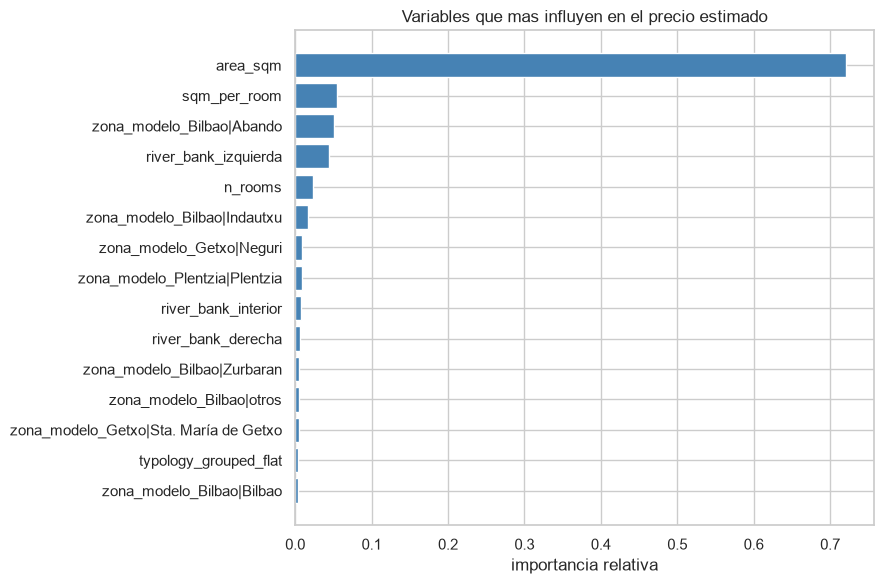


PESO POR TIPO DE INFORMACION
  Superficie          72.1 %
  Habitaciones         7.9 %
  Tipologia            0.6 %
  Zona                13.5 %
  Margen de la ria     6.0 %


In [3]:
# QUE VARIABLES PESAN MAS
#
# Importancia por reduccion de impureza: mide cuanto contribuye
# cada variable a mejorar las predicciones del modelo.

imp = (pd.DataFrame({"variable": nombres,
                     "importancia": modelo.feature_importances_})
       .sort_values("importancia", ascending=False))

print("LAS 15 VARIABLES MAS INFLUYENTES")
print(imp.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
top = imp.head(15).iloc[::-1]
ax.barh(top["variable"], top["importancia"], color="steelblue")
ax.set_xlabel("importancia relativa")
ax.set_title("Variables que mas influyen en el precio estimado")
plt.tight_layout()
plt.show()

# Agrupado por tipo de variable
grupos = {
    "Superficie": ["area_sqm"],
    "Habitaciones": ["n_rooms", "sqm_per_room"],
    "Tipologia": [n for n in nombres if n.startswith("typology")],
    "Zona": [n for n in nombres if n.startswith("zona_modelo")],
    "Margen de la ria": [n for n in nombres if n.startswith("river_bank")],
}
print()
print("PESO POR TIPO DE INFORMACION")
for g, cols in grupos.items():
    peso = imp[imp["variable"].isin(cols)]["importancia"].sum()
    print(f"  {g:18s} {peso*100:5.1f} %")

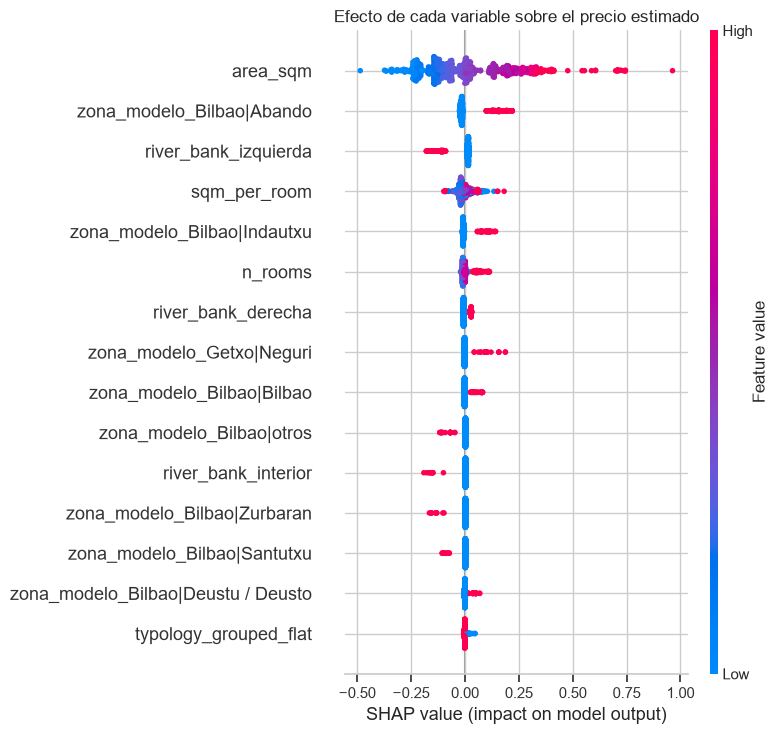

In [4]:
# SHAP: CUANTO SUMA O RESTA CADA VARIABLE
#
# La importancia dice QUE variables usa el modelo.
# SHAP dice ademas EN QUE DIRECCION: si mas metros suben el precio
# y cuanto, si estar en tal barrio lo baja.
#
# Cada punto del grafico es un anuncio. A la derecha del centro,
# esa variable empuja el precio hacia arriba; a la izquierda,
# hacia abajo. El color indica si el valor de la variable era
# alto (rojo) o bajo (azul).

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_trans)

shap.summary_plot(shap_values, X_trans, feature_names=nombres,
                  max_display=15, show=False)
plt.title("Efecto de cada variable sobre el precio estimado")
plt.tight_layout()
plt.show()

Anuncio seleccionado: 232
Valor base (log): 6.9511
Valor base equivalente: 1044.30 €
Predicción (log): 6.8938
Predicción equivalente: 986.14 €
Comprobación SHAP: 6.8938


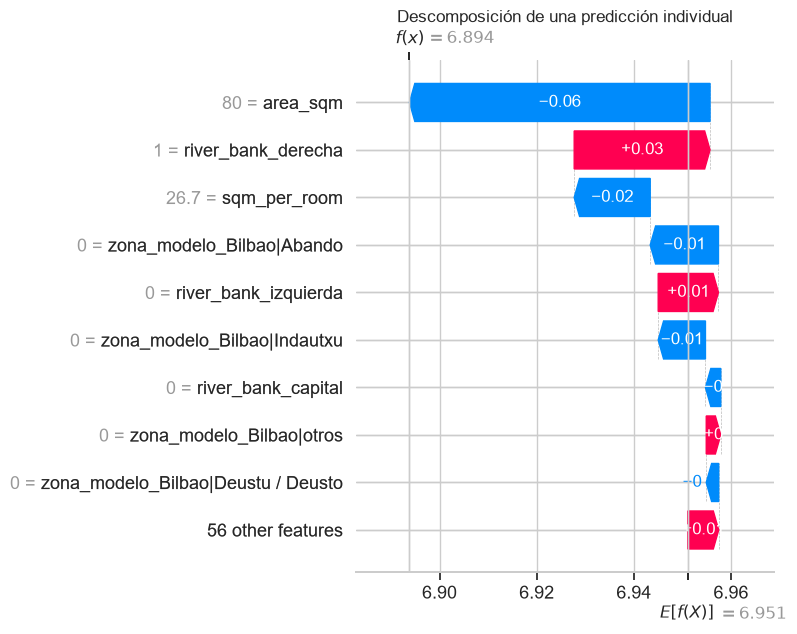

In [7]:
# SHAP: EXPLICACIÓN INDIVIDUAL

from scipy import sparse

# Predicción de todos los anuncios en la escala original (€)
pred_log = modelo.predict(X_trans)
pred_eur = np.exp(pred_log)

# Elegimos un anuncio representativo:
# el que tenga una predicción más próxima a la mediana
mediana_pred = np.median(pred_eur)
idx = np.argmin(np.abs(pred_eur - mediana_pred))

# Valor base del modelo
base_value = np.asarray(explainer.expected_value).reshape(-1)[0]

# Recuperar la fila explicada en formato compatible con SHAP
if sparse.issparse(X_trans):
    fila = X_trans[idx].toarray().ravel()
else:
    fila = np.asarray(X_trans[idx]).ravel()

# Construir una explicación SHAP individual
explicacion = shap.Explanation(
    values=np.asarray(shap_values)[idx],
    base_values=base_value,
    data=fila,
    feature_names=nombres
)

# Información para comprobar la interpretación
print(f"Anuncio seleccionado: {idx}")
print(f"Valor base (log): {base_value:.4f}")
print(f"Valor base equivalente: {np.exp(base_value):.2f} €")
print(f"Predicción (log): {pred_log[idx]:.4f}")
print(f"Predicción equivalente: {pred_eur[idx]:.2f} €")
print(
    f"Comprobación SHAP: "
    f"{base_value + np.asarray(shap_values)[idx].sum():.4f}"
)

# Gráfico waterfall
shap.plots.waterfall(
    explicacion,
    max_display=10,
    show=False
)

plt.title("Descomposición de una predicción individual")
plt.tight_layout()
plt.show()

In [5]:
# POR QUE ESTE PISO CUESTA ESTO
#
# Se toman tres anuncios (uno barato, uno medio y uno caro) y se
# desglosa como el modelo llega a su estimacion.
#
# Se parte de un precio base (la media de todos) y cada
# caracteristica suma o resta hasta llegar al precio final.

base = float(np.exp(np.ravel(explainer.expected_value)[0]))
print(f"Precio base del modelo: {base:.0f} EUR")
print("(el punto de partida antes de mirar ninguna caracteristica)")
print()

# Se eligen tres casos por percentiles en lugar de los extremos.
# El mas barato y el mas caro del conjunto son casos singulares que
# no representan el mercado; los percentiles 10, 50 y 90 dan
# ejemplos tipicos de gama baja, media y alta.
idx_ejemplos = [
    df["monthly_price"].sub(df["monthly_price"].quantile(0.10)).abs().idxmin(),
    df["monthly_price"].sub(df["monthly_price"].quantile(0.50)).abs().idxmin(),
    df["monthly_price"].sub(df["monthly_price"].quantile(0.90)).abs().idxmin(),
]

for etiqueta, idx in zip(["GAMA BAJA (p10)", "TIPICO (mediana)", "GAMA ALTA (p90)"], idx_ejemplos):
    pos = df.index.get_loc(idx)
    real = df.loc[idx, "monthly_price"]
    pred = np.exp(pipe.predict(X.iloc[[pos]]))[0]

    print(f"--- {etiqueta} ---")
    print(f"  {df.loc[idx, 'zona_modelo']} | "
          f"{df.loc[idx, 'area_sqm']:.0f} m2 | "
          f"{df.loc[idx, 'n_rooms']:.0f} hab | "
          f"{df.loc[idx, 'typology_grouped']}")
    print(f"  Precio real: {real:.0f} EUR | Estimado: {pred:.0f} EUR")

    contrib = pd.DataFrame({
        "variable": nombres,
        "efecto": shap_values[pos],
    })
    contrib = contrib[contrib["efecto"].abs() > 0.001]
    contrib = contrib.reindex(contrib["efecto"].abs().sort_values(ascending=False).index)

    print("  Lo que mas influye:")
    for _, r in contrib.head(5).iterrows():
        signo = "sube" if r["efecto"] > 0 else "baja"
        print(f"     {r['variable']:32s} {signo} {abs(r['efecto'])*100:5.1f} %")
    print()

Precio base del modelo: 1044 EUR
(el punto de partida antes de mirar ninguna caracteristica)

--- GAMA BAJA (p10) ---
  Santurtzi|otros | 60 m2 | 2 hab | flat
  Precio real: 750 EUR | Estimado: 714 EUR
  Lo que mas influye:
     area_sqm                         baja  20.5 %
     river_bank_izquierda             baja  10.9 %
     zona_modelo_Bilbao|Abando        baja   1.9 %
     sqm_per_room                     baja   1.6 %
     n_rooms                          baja   1.2 %

--- TIPICO (mediana) ---
  Leioa|otros | 106 m2 | 3 hab | flat
  Precio real: 990 EUR | Estimado: 1122 EUR
  Lo que mas influye:
     area_sqm                         sube  18.9 %
     zona_modelo_Leioa|otros          baja   8.5 %
     sqm_per_room                     baja   3.9 %
     river_bank_derecha               sube   2.1 %
     zona_modelo_Bilbao|Abando        baja   2.0 %

--- GAMA ALTA (p90) ---
  Bilbao|Indautxu | 130 m2 | 4 hab | flat
  Precio real: 1600 EUR | Estimado: 1550 EUR
  Lo que mas influye:
  

In [6]:
# Se guarda el modelo entrenado para que lo use la API.
# Con joblib se conserva el pipeline completo: transformaciones
# y modelo juntos, de forma que la API solo tenga que pasarle
# los datos en bruto.

import joblib, os

os.makedirs("../models/artifacts", exist_ok=True)
joblib.dump(pipe, "../models/artifacts/price_model.pkl")
joblib.dump({"numericas": NUMERICAS, "categoricas": CATEGORICAS,
             "nombres_transformados": nombres},
            "../models/artifacts/price_model_meta.pkl")

print("Modelo guardado en models/artifacts/price_model.pkl")
print(f"Tamano: {os.path.getsize('../models/artifacts/price_model.pkl')/1024:.0f} KB")

Modelo guardado en models/artifacts/price_model.pkl
Tamano: 382 KB
